In [27]:
import pandas as pd
df_train=pd.read_csv('train_data_v2.csv',index_col=0)
df_test=pd.read_csv('test_day3_v2.csv',index_col=0)
result_test_bid_id=df_test['bid_id'].copy()

In [28]:
df_train[df_train.select_dtypes(include='float64').columns] = df_train.select_dtypes(include='float64').astype('float32')
df_test[df_test.select_dtypes(include='float64').columns] = df_test.select_dtypes(include='float64').astype('float32')
df_train[df_train.select_dtypes(include='int64').columns] = df_train.select_dtypes(include='int64').astype('int32')
df_test[df_test.select_dtypes(include='int64').columns] = df_test.select_dtypes(include='int64').astype('int32')


In [29]:
df_test=df_test.drop(columns=['bid_id'])

In [30]:
df_train.shape

(1760309, 528)

In [31]:
df_test.shape

(446650, 527)

In [32]:
from sklearn.model_selection import train_test_split

In [33]:
y=df_train['click'].astype(int)
X=df_train.drop(columns=['click'])

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)
X_test = df_test[X_train.columns]

### LR訓練

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve,make_scorer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

AUC: 0.8694
AUC: 0.8644


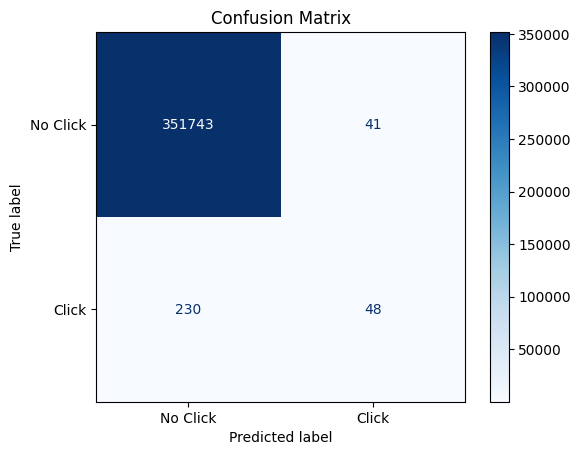

In [26]:
lr = LogisticRegression(max_iter=500)
lr.fit(X_train, y_train)
y_train_proba = lr.predict_proba(X_train)[:, 1]
auc_train = roc_auc_score(y_train, y_train_proba)
print(f"AUC: {auc_train:.4f}")
y_pred_proba = lr.predict_proba(X_valid)[:, 1]
auc = roc_auc_score(y_valid, y_pred_proba)
y_pred = (y_pred_proba >= 0.5).astype(int)
print(f"AUC: {auc:.4f}")
tn, fp, fn, tp = confusion_matrix(y_valid, y_pred).ravel()
cm = confusion_matrix(y_valid, y_pred)
labels = ["No Click", "Click"]  # 類別名稱
# 畫圖
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix_lr.png", dpi=300, bbox_inches="tight")  # dpi 可調整解析度
plt.show()

### XGBoost

In [13]:
import xgboost as xgb
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

[0]	train-auc:0.70887	val-auc:0.67756
[10]	train-auc:0.82074	val-auc:0.77280
[20]	train-auc:0.85086	val-auc:0.78530
[30]	train-auc:0.86661	val-auc:0.79041
[40]	train-auc:0.88054	val-auc:0.79352
[50]	train-auc:0.88972	val-auc:0.79826
[60]	train-auc:0.89723	val-auc:0.79648
[70]	train-auc:0.91441	val-auc:0.81364
[80]	train-auc:0.92082	val-auc:0.81963
[90]	train-auc:0.92518	val-auc:0.82259
[100]	train-auc:0.92960	val-auc:0.82252
[110]	train-auc:0.93337	val-auc:0.82312
[120]	train-auc:0.93688	val-auc:0.82382
[128]	train-auc:0.93965	val-auc:0.82311
Validation AUC: 0.823866774158505


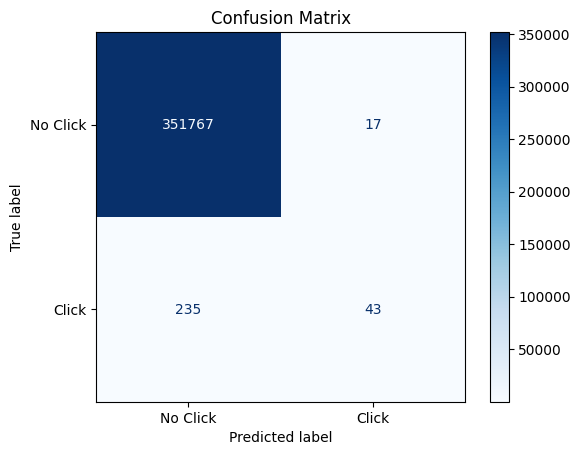

🔍 Threshold: 0.5
✅ True Positive Rate (Recall): 0.1547
⚠️ False Positive Rate (FPR): 0.0000


In [14]:
dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_valid, label=y_valid)

params = {
    'objective': 'binary:logistic',  # 二元分類
    'eval_metric': 'auc',           # 直接看 AUC
    'eta': 0.1,                     # 學習率
    'max_depth': 6,                 # 樹深度
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'seed': 42
}
watchlist = [(dtrain, 'train'), (dval, 'val')]

model = xgb.train(
    params,
    dtrain,
    num_boost_round=500,         # 最多迭代 500 次
    early_stopping_rounds=20,    # 如果 20 次內沒提升就停
    evals=watchlist,
    verbose_eval=10              # 每 10 次顯示一次
)
# 預測機率
y_pred_proba = model.predict(dval)


# 計算 AUC
auc = roc_auc_score(y_valid, y_pred_proba)
print("Validation AUC:", auc)
threshold=0.5
y_pred = (y_pred_proba >= threshold).astype(int)

# 計算混淆矩陣
tn, fp, fn, tp = confusion_matrix(y_valid, y_pred).ravel()
cm = confusion_matrix(y_valid, y_pred)
labels = ["No Click", "Click"]  # 類別名稱
# 畫圖
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix_xgboost.png", dpi=300, bbox_inches="tight")  # dpi 可調整解析度
plt.show()
# 1. True Positive Rate（Recall）
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
# 2. False Positive Rate（FPR）
fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

# 輸出結果
print(f"🔍 Threshold: {threshold}")
print(f"✅ True Positive Rate (Recall): {recall:.4f}")
print(f"⚠️ False Positive Rate (FPR): {fpr:.4f}")


In [15]:
#測試集部分
dtest = xgb.DMatrix(X_test)
y_test_proba = model.predict(dtest)  # 預測機率
y_test_pred = (y_test_proba >= threshold).astype(int)  # 轉成 0 或 1
y_test_pred_series = pd.Series(y_test_pred, index=df_test.index, name='click_predicted')
print(y_test_pred_series.head(5))

0    0
1    0
2    0
3    0
4    0
Name: click_predicted, dtype: int64


#### Dicision Tree 篩選特徵 + XGBoost 分類

In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score
import xgboost as xgb
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from matplotlib import pyplot as plt

In [35]:
rf = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=5, random_state=42, n_jobs=-1)
rf.fit(X, y)
importances = rf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
top_20_features = feature_importance_df.sort_values(by='importance', ascending=False)['feature'].head(150).tolist()

In [36]:
#print("✅ Top 20 Features Selected:")
#print(top_20_features)
X_train_top20 = X_train[top_20_features]
X_valid_top20 = X_valid[top_20_features]

[0]	train-auc:0.75803	val-auc:0.78307
[10]	train-auc:0.85107	val-auc:0.86187
[20]	train-auc:0.87816	val-auc:0.88106
[30]	train-auc:0.89743	val-auc:0.89736
[40]	train-auc:0.90401	val-auc:0.90071
[50]	train-auc:0.92058	val-auc:0.90166
[60]	train-auc:0.93145	val-auc:0.90307
[61]	train-auc:0.93327	val-auc:0.90200
🎯 XGBoost Validation AUC: 0.90312


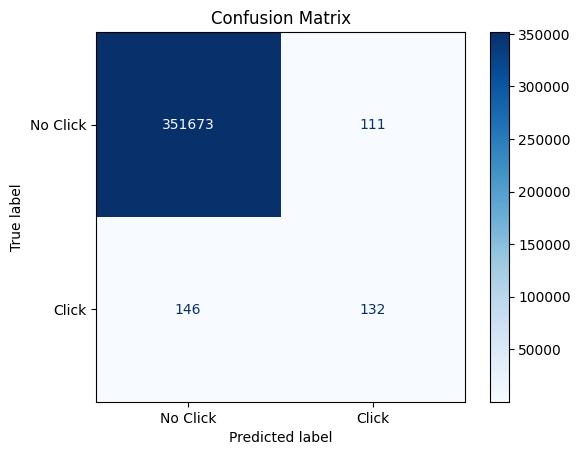


📌 Threshold: 0.4315
✅ True Positive Rate (Recall): 0.4748
⚠️ False Positive Rate (FPR): 0.0003


In [37]:
dtrain = xgb.DMatrix(X_train_top20, label=y_train)
dval = xgb.DMatrix(X_valid_top20, label=y_valid)

params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'eta': 0.1,
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'scale_pos_weight':10,
    'seed': 42
}

watchlist = [(dtrain, 'train'), (dval, 'val')]
model = xgb.train(params, dtrain, num_boost_round=500, early_stopping_rounds=20, evals=watchlist, verbose_eval=10)

y_pred_proba = model.predict(dval)
auc = roc_auc_score(y_valid, y_pred_proba)
print(f"🎯 XGBoost Validation AUC: {auc:.5f}")

# 7️⃣ 額外：你要的 recall / fpr（可選閾值 threshold）

threshold = 0.4315
y_pred = (y_pred_proba >= threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(y_valid, y_pred).ravel()

cm = confusion_matrix(y_valid, y_pred)
labels = ["No Click", "Click"]  # 類別名稱
# 畫圖
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
# 儲存圖片（在 show() 前）
plt.savefig("confusion_matrix_xgboost+randomforest.png", dpi=300, bbox_inches="tight")  # dpi 可調整解析度
plt.show()

recall = tp / (tp + fn) if (tp + fn) > 0 else 0
fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

print(f"\n📌 Threshold: {threshold}")
print(f"✅ True Positive Rate (Recall): {recall:.4f}")
print(f"⚠️ False Positive Rate (FPR): {fpr:.4f}")

C:\Users\user\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


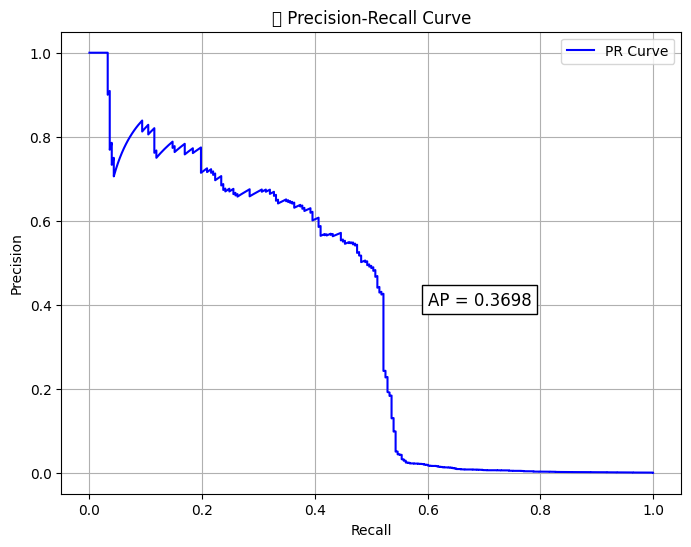


🏆 Best Threshold (F1): 0.4345
📈 Best F1 Score: 0.5067


In [20]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# 計算 precision, recall, thresholds
precision, recall, thresholds = precision_recall_curve(y_valid, y_pred_proba)

# 畫圖
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label="PR Curve", color="b")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("📈 Precision-Recall Curve")
plt.grid(True)
plt.legend()

# 加上 Average Precision
ap_score = average_precision_score(y_valid, y_pred_proba)
plt.text(0.6, 0.4, f"AP = {ap_score:.4f}", fontsize=12, bbox=dict(facecolor='white', edgecolor='black'))

plt.show()
from sklearn.metrics import f1_score

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"\n🏆 Best Threshold (F1): {best_threshold:.4f}")
print(f"📈 Best F1 Score: {best_f1:.4f}")


In [38]:
#測試集部分
X_test=X_test[top_20_features]
dtest = xgb.DMatrix(X_test)
y_test_proba = model.predict(dtest)  # 預測機率
y_test_pred = (y_test_proba >= threshold).astype(int)  # 轉成 0 或 1
y_test_pred_series = pd.Series(y_test_pred, index=df_test.index, name='click_predicted')
y_test_proba_series = pd.Series(y_test_proba, index=df_test.index, name='click_predicted_proba')
print(y_test_proba_series.head(5))

0    0.001178
1    0.001123
2    0.001276
3    0.001331
4    0.001243
Name: click_predicted_proba, dtype: float32


#### gridsearch

### DNN

### 寫入Test

In [57]:
df_result=pd.DataFrame({'bid_id':result_test_bid_id,
                        'paying_price':0})
df_result['click_predicted']=y_test_pred_series
df_result['click_probability']=y_test_proba_series
df_high_prob_095= df_result[df_result['click_probability'] > 0.95]
df_high_prob_085 = df_result[(0.95>df_result['click_probability']) & (df_result['click_probability']>0.85)]
df_high_prob_075 = df_result[(0.85>df_result['click_probability']) & (df_result['click_probability']>0.75)]
df_high_prob_last = df_result[(0.75>df_result['click_probability']) & (df_result['click_probability']>threshold)]
# 當預測為 click 時，把 paying_price 設為 400
#df_result.loc[df_result['click_predicted'] == 1, 'paying_price'] = 350
print(f'大於threholds:{len(df_result[df_result["click_probability"]>threshold])}')
print(f"大於0.9:{len(df_high_prob_095)}")
print(f"大於0.85小於0.95:{len(df_high_prob_085)}")
print(f"大於0.75小於0.85:{len(df_high_prob_075)}")
print(f"大於therholds小於0.75:{len(df_high_prob_last)}")

df_result.loc[df_result['click_probability'] > 0.95, 'paying_price'] = 450
df_result.loc[(df_result['click_probability'] > 0.85) & (df_result['click_probability'] <= 0.95), 'paying_price'] = 400
df_result.loc[(df_result['click_probability'] > 0.75) & (df_result['click_probability'] <= 0.85), 'paying_price'] = 350
df_result.loc[(df_result['click_probability'] > threshold) & (df_result['click_probability'] <= 0.75), 'paying_price'] = 300
# 其餘預設 0，不出價



大於threholds:581
大於0.9:53
大於0.85小於0.95:180
大於0.75小於0.85:122
大於therholds小於0.75:226


In [ ]:
df_result['paying_price'].value_counts()
df_result.head(5)

paying_price
0      446069
300       226
400       180
350       122
450        53
Name: count, dtype: int64

In [23]:
df_result=df_result.drop(columns=['click_predicted'])

In [24]:
df_result['paying_price'].value_counts()

paying_price
0      446069
350       581
Name: count, dtype: int64

In [25]:
df_result.to_csv('F14101066_day3.csv', index=False)